# Projet Deep Learning : Classification d'Herbiers avec CrossViT

Ce notebook permet de lancer l'entraînement des configurations A, B, C1, C2.

## Configuration de l'environnement
Si vous exécutez ce notebook sur Google Colab (même connecté depuis VS Code), les fichiers du projet doivent être présents sur la machine distante.

La cellule suivante vérifie si le projet est présent. Sinon, elle vous invite à uploader `project.zip`.

## 1. Installation des dépendances

## 2. Vérification des Données

## 3. Définition des Modules du Projet
Pour faciliter l'exécution sur Colab, l'ensemble du code (Config, Dataset, Model, Trainer) est défini ci-dessous.

In [24]:
# Update pip to the latest version
!pip install --upgrade pip

# Install all required libraries
%pip install torch torchvision torchaudio pillow numpy tqdm einops scikit-learn matplotlib pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
# === IMPORTS ===
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image, ImageFile
import numpy as np
from tqdm.notebook import tqdm
from einops import rearrange, repeat
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt

ImageFile.LOAD_TRUNCATED_IMAGES = True

In [26]:
# === CONFIGURATION ===
class Config:
    # Paths
    PROJECT_ROOT = os.getcwd()
    DATA_ROOT = os.path.join(PROJECT_ROOT, 'Data_Projet')

    # Subfolders
    UNSEG_DIR = 'mission_herbonaute_2000'
    SEG_DIR = 'mission_herbonaute_2000_seg_black'
    MASK_DIR = 'masks'
    LABELS_FILE = 'cleaned_labels.csv'

    # Checkpoints
    CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, 'checkpoints')

    # Model
    IMAGE_SIZE = 224
    PATCH_SIZE = 16
    NUM_CLASSES = 2

    # Training
    BATCH_SIZE = 32
    LR = 1e-4
    WEIGHT_DECAY = 1e-4
    EPOCHS = 10 # Can be overridden
    NUM_WORKERS = 2 # Reduced for Colab safety
    SEED = 42

    # Patch Weighting
    WEIGHTING_FUNC = 'linear'
    GAMMA = 1.0

    # Methods: 'A', 'B', 'C1', 'C2'
    CONFIGURATION = 'C1'

    @staticmethod
    def makedirs():
        os.makedirs(Config.CHECKPOINT_DIR, exist_ok=True)

In [27]:
# === UTILS (Metrics, Weighting, Loss) ===

def calculate_metrics(preds, targets):
    preds_np = preds.detach().cpu().numpy()
    targets_np = targets.detach().cpu().numpy()
    acc = accuracy_score(targets_np, preds_np)
    f1 = f1_score(targets_np, preds_np, average='weighted')
    return acc, f1

def calculate_iou(heatmap, mask, threshold=0.5):
    if isinstance(heatmap, torch.Tensor):
        heatmap = heatmap.detach().cpu().numpy()
    if isinstance(mask, torch.Tensor):
        mask = mask.detach().cpu().numpy()
    heatmap_bin = (heatmap > threshold).astype(float)
    intersection = np.logical_and(heatmap_bin, mask).sum()
    union = np.logical_or(heatmap_bin, mask).sum()
    if union == 0: return 0.0
    return intersection / union

class IoULoss(nn.Module):
    def __init__(self, weight=1.0, iou_lambda=0.0):
        super().__init__()
        self.ce_loss = nn.CrossEntropyLoss(weight=weight)
        self.iou_lambda = iou_lambda

    def forward(self, outputs, targets, attention_maps=None, masks=None):
        loss = self.ce_loss(outputs, targets)
        if self.iou_lambda > 0 and attention_maps is not None and masks is not None:
            pass # Optimization logic placeholder
        return loss

def compute_patch_counts(mask, patch_size=16):
    B, C, H, W = mask.shape
    patches = mask.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
    ratios = patches.mean(dim=(-1, -2))
    ratios = ratios.flatten(2).transpose(1, 2).squeeze(-1)
    return ratios


In [28]:
# === DATASET ===
class HerbariumDataset(Dataset):
    def __init__(self, root_dir, samples, transform=None, patch_size=16, return_mask_ratio=False,
                 unseg_dir='unsegmented', seg_dir='segmented', mask_dir='masks'):
        self.root_dir = root_dir
        self.samples = samples
        self.transform = transform
        self.return_mask_ratio = return_mask_ratio
        self.patch_size = patch_size
        self.unseg_dir = os.path.join(root_dir, unseg_dir)
        self.seg_dir = os.path.join(root_dir, seg_dir)
        self.mask_dir = os.path.join(root_dir, mask_dir)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filename, label = self.samples[idx]
        unseg_path = os.path.join(self.unseg_dir, filename)
        seg_path = os.path.join(self.seg_dir, filename)

        try:
            img_unseg = Image.open(unseg_path).convert('RGB')
            img_seg = Image.open(seg_path).convert('RGB')
        except Exception as e:
            print(f"Error loading {filename}: {e}")
            raise e

        mask_ratio = torch.tensor(0.0)
        if self.return_mask_ratio:
            mask_path = os.path.join(self.mask_dir, filename)
            if os.path.exists(mask_path):
                 mask = Image.open(mask_path).convert('L')
            else:
                if img_seg.mode == 'RGBA':
                    mask = img_seg.split()[-1]
                else:
                    img_gray = img_seg.convert('L')
                    mask = img_gray.point(lambda x: 255 if x > 10 else 0, mode='1')

        if self.transform:
            img_unseg = self.transform(img_unseg)
            img_seg = self.transform(img_seg)
            if self.return_mask_ratio:
                mask = mask.resize((img_unseg.shape[2], img_unseg.shape[1]), Image.NEAREST)
                mask_tensor = torch.from_numpy(np.array(mask)).float() / 255.0
                patches = mask_tensor.unfold(0, self.patch_size, self.patch_size).unfold(1, self.patch_size, self.patch_size)
                ratios = patches.mean(dim=(2, 3)).flatten()
                mask_ratio = ratios

        return img_unseg, img_seg, mask_ratio, torch.tensor(label, dtype=torch.long)

In [29]:
# === MODEL: CrossViT ===
class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x

class Attention(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=False, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x, patch_weights=None):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)

        if patch_weights is not None:
             if patch_weights.shape[1] == N - 1:
                 w_cls = torch.ones((B, 1), device=patch_weights.device)
                 weights = torch.cat((w_cls, patch_weights), dim=1)
             else:
                 weights = patch_weights
             w_in = weights.unsqueeze(1).unsqueeze(-1)
             v = v * w_in

        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x, attn

class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class Block(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, drop=0., attn_drop=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads=num_heads, qkv_bias=qkv_bias, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = Mlp(in_features=dim, hidden_features=int(dim * mlp_ratio), drop=drop)

    def forward(self, x, patch_weights=None):
        y, attn = self.attn(self.norm1(x), patch_weights=patch_weights)
        x = x + y
        x = x + self.mlp(self.norm2(x))
        return x, attn

class CrossAttention(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=False, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5
        self.wc = nn.Linear(dim, dim, bias=qkv_bias)
        self.wa = nn.Linear(dim, dim, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x_cls, x_patch):
        B, _, C = x_cls.shape
        q = self.wc(x_cls).reshape(B, 1, self.num_heads, C // self.num_heads).permute(0, 2, 1, 3)
        k = self.wa(x_patch).reshape(B, -1, self.num_heads, C // self.num_heads).permute(0, 2, 1, 3)
        v = k
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, 1, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

class CrossViT(nn.Module):
    def __init__(self, img_size=224, num_classes=1000,
                 small_dim=192, small_patch_size=16, small_depth=12, small_heads=3,
                 large_dim=384, large_patch_size=32, large_depth=12, large_heads=6,
                 cross_fusion_layers=[3, 6, 9],
                 single_branch=False, branch_type='large'):
        super().__init__()
        self.single_branch = single_branch
        self.branch_type = branch_type

        if not single_branch or branch_type == 'small':
            self.small_patch_embed = PatchEmbed(img_size, small_patch_size, embed_dim=small_dim)
            self.small_cls_token = nn.Parameter(torch.zeros(1, 1, small_dim))
            self.small_pos_embed = nn.Parameter(torch.zeros(1, 1 + self.small_patch_embed.num_patches, small_dim))
            self.small_blocks = nn.ModuleList([Block(small_dim, small_heads) for _ in range(small_depth)])
            self.small_norm = nn.LayerNorm(small_dim)

        if not single_branch or branch_type == 'large':
            self.large_patch_embed = PatchEmbed(img_size, large_patch_size, embed_dim=large_dim)
            self.large_cls_token = nn.Parameter(torch.zeros(1, 1, large_dim))
            self.large_pos_embed = nn.Parameter(torch.zeros(1, 1 + self.large_patch_embed.num_patches, large_dim))
            self.large_blocks = nn.ModuleList([Block(large_dim, large_heads) for _ in range(large_depth)])
            self.large_norm = nn.LayerNorm(large_dim)

        if not single_branch:
            self.cross_fusion_layers = cross_fusion_layers
            self.cross_attn_s2l = nn.ModuleList([CrossAttention(large_dim) for _ in cross_fusion_layers])
            self.cross_attn_l2s = nn.ModuleList([CrossAttention(small_dim) for _ in cross_fusion_layers])
            self.proj_l2s = nn.ModuleList([nn.Linear(large_dim, small_dim) for _ in cross_fusion_layers])
            self.proj_s2l = nn.ModuleList([nn.Linear(small_dim, large_dim) for _ in cross_fusion_layers])

        self.head = nn.Linear(large_dim + small_dim if not single_branch else (small_dim if branch_type=='small' else large_dim), num_classes)

    def forward(self, x_small, x_large=None):
        if self.single_branch:
            x = x_small if self.branch_type == 'small' else (x_large if x_large is not None else x_small)
            if self.branch_type == 'small':
                B = x.shape[0]
                x = self.small_patch_embed(x)
                cls_token = self.small_cls_token.expand(B, -1, -1)
                x = torch.cat((cls_token, x), dim=1)
                x = x + self.small_pos_embed
                atts = []
                for blk in self.small_blocks:
                    x, att = blk(x)
                    atts.append(att)
                cls = self.small_norm(x)[:, 0]
                return self.head(cls), atts
            else:
                B = x.shape[0]
                x = self.large_patch_embed(x)
                cls_token = self.large_cls_token.expand(B, -1, -1)
                x = torch.cat((cls_token, x), dim=1)
                x = x + self.large_pos_embed
                atts = []
                for blk in self.large_blocks:
                    x, att = blk(x)
                    atts.append(att)
                cls = self.large_norm(x)[:, 0]
                return self.head(cls), atts

        B = x_small.shape[0]
        x_s = self.small_patch_embed(x_small)
        cls_s = self.small_cls_token.expand(B, -1, -1)
        x_s = torch.cat((cls_s, x_s), dim=1)
        x_s = x_s + self.small_pos_embed
        x_l = self.large_patch_embed(x_large)
        cls_l = self.large_cls_token.expand(B, -1, -1)
        x_l = torch.cat((cls_l, x_l), dim=1)
        x_l = x_l + self.large_pos_embed

        all_attns_s = []
        all_attns_l = []
        f_idxs = self.cross_fusion_layers

        for i in range(len(self.small_blocks)):
            x_s, attn_s = self.small_blocks[i](x_s)
            x_l, attn_l = self.large_blocks[i](x_l)
            all_attns_s.append(attn_s)
            all_attns_l.append(attn_l)
            if i in f_idxs:
                idx = f_idxs.index(i)
                cls_s_proj = self.proj_s2l[idx](x_s[:, 0:1])
                cls_s_new = self.cross_attn_s2l[idx](cls_s_proj, x_l)
                x_l[:, 0:1] = x_l[:, 0:1] + cls_s_new
                cls_l_proj = self.proj_l2s[idx](x_l[:, 0:1])
                cls_l_new = self.cross_attn_l2s[idx](cls_l_proj, x_s)
                x_s[:, 0:1] = x_s[:, 0:1] + cls_l_new

        x_s = self.small_norm(x_s)
        x_l = self.large_norm(x_l)
        cls_concat = torch.cat((x_s[:, 0], x_l[:, 0]), dim=1)
        return self.head(cls_concat), (all_attns_s, all_attns_l)

def get_model(config_name='C1', num_classes=2):
    if config_name == 'A':
        return CrossViT(single_branch=True, branch_type='large', num_classes=num_classes)
    elif config_name == 'B':
        return CrossViT(single_branch=True, branch_type='large', num_classes=num_classes)
    elif config_name == 'C1':
        return CrossViT(single_branch=False, num_classes=num_classes)
    elif config_name == 'C2':
        return CrossViT(single_branch=False, num_classes=num_classes)
    else:
        raise ValueError(f"Unknown config {config_name}")

In [30]:
# === TRAINER ===
class Trainer:
    def __init__(self, model, train_loader, val_loader, criterion, optimizer, config, device='cuda'):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.config = config
        self.device = device
        self.model.to(device)

    def train_epoch(self, epoch):
        self.model.train()
        running_loss = 0.0
        all_preds, all_targets = [], []

        pbar = tqdm(self.train_loader, desc=f"Train Epoch {epoch}")
        for batch in pbar:
            img_unseg, img_seg, mask_ratio, targets = [x.to(self.device) for x in batch]
            self.optimizer.zero_grad()

            if self.config.CONFIGURATION == 'A':
                outputs, attns = self.model(x_small=img_unseg)
            elif self.config.CONFIGURATION == 'B':
                outputs, attns = self.model(x_small=img_seg)
            elif self.config.CONFIGURATION == 'C1':
                outputs, attns = self.model(x_small=img_unseg, x_large=img_seg)
            elif self.config.CONFIGURATION == 'C2':
                outputs, attns = self.model(x_small=img_seg, x_large=img_unseg)

            loss = self.criterion(outputs, targets, attention_maps=attns)
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            pbar.set_postfix({'loss': loss.item()})

        epoch_loss = running_loss / len(self.train_loader)
        return epoch_loss

    def validate(self, epoch):
        self.model.eval()
        running_loss = 0.0
        all_preds, all_targets = [], []

        with torch.no_grad():
            for batch in tqdm(self.val_loader, desc=f"Val Epoch {epoch}"):
                img_unseg, img_seg, mask_ratio, targets = [x.to(self.device) for x in batch]
                if self.config.CONFIGURATION == 'A':
                    outputs, attns = self.model(x_small=img_unseg)
                elif self.config.CONFIGURATION == 'B':
                    outputs, attns = self.model(x_small=img_seg)
                elif self.config.CONFIGURATION == 'C1':
                    outputs, attns = self.model(x_small=img_unseg, x_large=img_seg)
                elif self.config.CONFIGURATION == 'C2':
                    outputs, attns = self.model(x_small=img_seg, x_large=img_unseg)
                loss = self.criterion(outputs, targets)
                running_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                all_preds.append(preds)
                all_targets.append(targets)
        all_preds = torch.cat(all_preds)
        all_targets = torch.cat(all_targets)
        acc, f1 = calculate_metrics(all_preds, all_targets)
        print(f"Epoch {epoch} | Val Loss: {running_loss/len(self.val_loader):.4f} | Acc: {acc:.4f} | F1: {f1:.4f}")
        return acc, f1

    def train(self):
        best_f1 = 0.0
        history = {'train_loss': [], 'val_acc': [], 'val_f1': []}
        for epoch in range(1, self.config.EPOCHS + 1):
            train_loss = self.train_epoch(epoch)
            acc, f1 = self.validate(epoch)
            history['train_loss'].append(train_loss)
            history['val_acc'].append(acc)
            history['val_f1'].append(f1)
            if f1 > best_f1:
                best_f1 = f1
                torch.save(self.model.state_dict(), f"{self.config.CHECKPOINT_DIR}/best_model_{self.config.CONFIGURATION}.pth")
        return history

## 4. Lancement des Expérimentations
Configurations A, B, C1, C2.
Les résultats (historique) seront sauvegardés dans `results/`.

In [31]:
# === RUN ALL CONFIGS ===
configs = ['A', 'B', 'C1', 'C2']
epochs = 10

Config.makedirs()
os.makedirs(os.path.join(Config.PROJECT_ROOT, 'results'), exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Check Data
csv_path = os.path.join(Config.DATA_ROOT, Config.LABELS_FILE)
if not os.path.exists(csv_path):
    print(f"Cleaned CSV not found at {csv_path}. Please ensure data is loaded.")
else:
    print(f"Loading cleaned labels from {csv_path}...")
    import pandas as pd
    df = pd.read_csv(csv_path)
    samples = []
    for idx, row in df.iterrows():
        samples.append((row['filename'], int(row['label'])))
    print(f"Loaded {len(samples)} valid samples for training.")

    # Transforms
    transform = transforms.Compose([
        transforms.Resize((Config.IMAGE_SIZE, Config.IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # Datasets
    full_dataset = HerbariumDataset(Config.DATA_ROOT, samples, transform=transform,
                                    unseg_dir=Config.UNSEG_DIR, seg_dir=Config.SEG_DIR)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=Config.NUM_WORKERS)
    val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS)

    for conf in configs:
        print(f"\n--- Configuration {conf} ---")
        Config.CONFIGURATION = conf
        Config.EPOCHS = epochs

        model = get_model(Config.CONFIGURATION, num_classes=Config.NUM_CLASSES)
        criterion = IoULoss(weight=None)
        optimizer = torch.optim.AdamW(model.parameters(), lr=Config.LR, weight_decay=Config.WEIGHT_DECAY)

        trainer = Trainer(model, train_loader, val_loader, criterion, optimizer, Config, device=device)
        history = trainer.train()

        # Save History
        results_dir = os.path.join(Config.PROJECT_ROOT, 'results')
        with open(os.path.join(results_dir, f'history_{Config.CONFIGURATION}.json'), 'w') as f:
            json.dump(history, f)
        print(f"Training finished for {Config.CONFIGURATION}. Results saved.")

Using device: cpu
Cleaned CSV not found at c:\Users\nouss\Desktop\DL\projet\Data_Projet\cleaned_labels.csv. Please ensure data is loaded.


## 5. Visualisation
Comparaison des F1-Scores.

C:\Users\nouss\AppData\Local\Temp\ipykernel_29984\3842377900.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


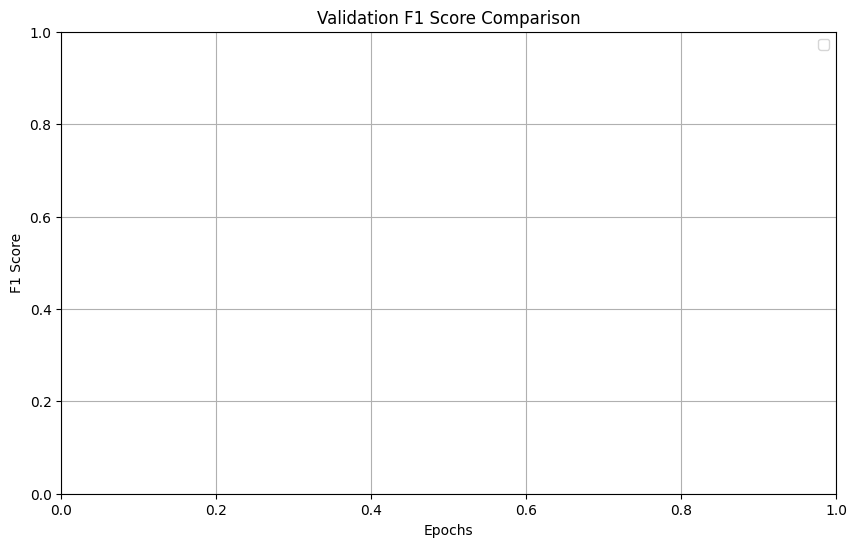

In [32]:
import matplotlib.pyplot as plt
results_dir = os.path.join(Config.PROJECT_ROOT, 'results')

if os.path.exists(results_dir):
    plt.figure(figsize=(10, 6))
    files = [f for f in os.listdir(results_dir) if f.startswith('history_') and f.endswith('.json')]

    for f in files:
        config_name = f.replace('history_', '').replace('.json', '')
        path = os.path.join(results_dir, f)
        with open(path, 'r') as json_file:
            history = json.load(json_file)
        f1_scores = history.get('val_f1', [])
        epochs_range = range(1, len(f1_scores) + 1)
        plt.plot(epochs_range, f1_scores, label=f'Config {config_name}')

    plt.title('Validation F1 Score Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No results to display.")

In [33]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image, ImageFile
import numpy as np
from tqdm.notebook import tqdm
from einops import rearrange, repeat
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt

ImageFile.LOAD_TRUNCATED_IMAGES = True # Added this line to handle truncated images

# === CONFIGURATION ===
class Config:
    # Paths
    PROJECT_ROOT = os.getcwd()
    # DATA_ROOT for images
    DATA_ROOT = os.path.join(PROJECT_ROOT, 'Data_Projet')
    # LABELS_DATA_ROOT for the labels CSV file - Corrected path
    LABELS_DATA_ROOT = os.path.join(PROJECT_ROOT, 'Data_Projet')

    # Subfolders (these are relative to DATA_ROOT, so no need for full paths here)
    UNSEG_DIR = 'mission_herbonaute_2000'
    SEG_DIR = 'mission_herbonaute_2000_seg_black'
    MASK_DIR = 'masks'
    LABELS_FILE = 'cleaned_labels.csv'

    # Checkpoints
    CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, 'checkpoints')

    # Model
    IMAGE_SIZE = 224
    PATCH_SIZE = 16
    NUM_CLASSES = 2

    # Training
    BATCH_SIZE = 32
    LR = 1e-4
    WEIGHT_DECAY = 1e-4
    EPOCHS = 5 # Can be overridden
    NUM_WORKERS = 2 # Reduced for Colab safety
    SEED = 42

    # Patch Weighting
    WEIGHTING_FUNC = 'linear'
    GAMMA = 1.0

    # Methods: 'A', 'B', 'C1', 'C2'
    CONFIGURATION = 'C1'

    @staticmethod
    def makedirs():
        os.makedirs(Config.CHECKPOINT_DIR, exist_ok=True)

# === UTILS (Metrics, Weighting, Loss) ===
def calculate_metrics(preds, targets):
    preds_np = preds.detach().cpu().numpy()
    targets_np = targets.detach().cpu().numpy()
    acc = accuracy_score(targets_np, preds_np)
    f1 = f1_score(targets_np, preds_np, average='weighted')
    return acc, f1

def calculate_iou(heatmap, mask, threshold=0.5):
    if isinstance(heatmap, torch.Tensor):
        heatmap = heatmap.detach().cpu().numpy()
    if isinstance(mask, torch.Tensor):
        mask = mask.detach().cpu().numpy()
    heatmap_bin = (heatmap > threshold).astype(float)
    intersection = np.logical_and(heatmap_bin, mask).sum()
    union = np.logical_or(heatmap_bin, mask).sum()
    if union == 0: return 0.0
    return intersection / union

class IoULoss(nn.Module):
    def __init__(self, weight=1.0, iou_lambda=0.0):
        super().__init__()
        self.ce_loss = nn.CrossEntropyLoss(weight=weight)
        self.iou_lambda = iou_lambda

    def forward(self, outputs, targets, attention_maps=None, masks=None):
        loss = self.ce_loss(outputs, targets)
        if self.iou_lambda > 0 and attention_maps is not None and masks is not None:
            pass # Optimization logic placeholder
        return loss

def compute_patch_counts(mask, patch_size=16):
    B, C, H, W = mask.shape
    patches = mask.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
    ratios = patches.mean(dim=(-1, -2))
    ratios = ratios.flatten(2).transpose(1, 2).squeeze(-1)
    return ratios

# === DATASET ===
class HerbariumDataset(Dataset):
    def __init__(self, root_dir, samples, transform=None, patch_size=16, return_mask_ratio=False,
                 unseg_dir=None, seg_dir=None, mask_dir=None):
        self.root_dir = root_dir
        self.samples = samples
        self.transform = transform
        self.return_mask_ratio = return_mask_ratio
        self.patch_size = patch_size
        # Use Config subdirectories here relative to root_dir
        self.unseg_dir = os.path.join(root_dir, Config.UNSEG_DIR if unseg_dir is None else unseg_dir)
        self.seg_dir = os.path.join(root_dir, Config.SEG_DIR if seg_dir is None else seg_dir)
        self.mask_dir = os.path.join(root_dir, Config.MASK_DIR if mask_dir is None else mask_dir)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filename, label = self.samples[idx]
        unseg_path = os.path.join(self.unseg_dir, filename)
        seg_path = os.path.join(self.seg_dir, filename)

        try:
            img_unseg = Image.open(unseg_path).convert('RGB')
            img_seg = Image.open(seg_path).convert('RGB')
        except Exception as e:
            print(f"Error loading {filename}: {e}")
            raise e

        mask_ratio = torch.tensor(0.0)
        if self.return_mask_ratio:
            mask_path = os.path.join(self.mask_dir, filename)
            if os.path.exists(mask_path):
                 mask = Image.open(mask_path).convert('L')
            else:
                if img_seg.mode == 'RGBA':
                    mask = img_seg.split()[-1]
                else:
                    img_gray = img_seg.convert('L')
                    mask = img_gray.point(lambda x: 255 if x > 10 else 0, mode='1')

        if self.transform:
            img_unseg = self.transform(img_unseg)
            img_seg = self.transform(img_seg)
            if self.return_mask_ratio:
                mask = mask.resize((img_unseg.shape[2], img_unseg.shape[1]), Image.NEAREST)
                mask_tensor = torch.from_numpy(np.array(mask)).float() / 255.0
                patches = mask_tensor.unfold(0, self.patch_size, self.patch_size).unfold(1, self.patch_size, self.patch_size)
                ratios = patches.mean(dim=(2, 3)).flatten()
                mask_ratio = ratios

        return img_unseg, img_seg, mask_ratio, torch.tensor(label, dtype=torch.long)

# === MODEL: CrossViT ===
class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x

class Attention(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=False, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x, patch_weights=None):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)

        if patch_weights is not None:
             if patch_weights.shape[1] == N - 1:
                 w_cls = torch.ones((B, 1), device=patch_weights.device)
                 weights = torch.cat((w_cls, patch_weights), dim=1)
             else:
                 weights = patch_weights
             w_in = weights.unsqueeze(1).unsqueeze(-1)
             v = v * w_in

        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x, attn

class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class Block(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, drop=0., attn_drop=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads=num_heads, qkv_bias=qkv_bias, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = Mlp(in_features=dim, hidden_features=int(dim * mlp_ratio), drop=drop)

    def forward(self, x, patch_weights=None):
        y, attn = self.attn(self.norm1(x), patch_weights=patch_weights)
        x = x + y
        x = x + self.mlp(self.norm2(x))
        return x, attn

class CrossAttention(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=False, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5
        self.wc = nn.Linear(dim, dim, bias=qkv_bias)
        self.wa = nn.Linear(dim, dim, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x_cls, x_patch):
        B, _, C = x_cls.shape
        q = self.wc(x_cls).reshape(B, 1, self.num_heads, C // self.num_heads).permute(0, 2, 1, 3)
        k = self.wa(x_patch).reshape(B, -1, self.num_heads, C // self.num_heads).permute(0, 2, 1, 3)
        v = k
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, 1, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

class CrossViT(nn.Module):
    def __init__(self, img_size=224, num_classes=1000,
                 small_dim=192, small_patch_size=16, small_depth=12, small_heads=3,
                 large_dim=384, large_patch_size=32, large_depth=12, large_heads=6,
                 cross_fusion_layers=[3, 6, 9],
                 single_branch=False, branch_type='large'):
        super().__init__()
        self.single_branch = single_branch
        self.branch_type = branch_type

        if not single_branch or branch_type == 'small':
            self.small_patch_embed = PatchEmbed(img_size, small_patch_size, embed_dim=small_dim)
            self.small_cls_token = nn.Parameter(torch.zeros(1, 1, small_dim))
            self.small_pos_embed = nn.Parameter(torch.zeros(1, 1 + self.small_patch_embed.num_patches, small_dim))
            self.small_blocks = nn.ModuleList([Block(small_dim, small_heads) for _ in range(small_depth)])
            self.small_norm = nn.LayerNorm(small_dim)

        if not single_branch or branch_type == 'large':
            self.large_patch_embed = PatchEmbed(img_size, large_patch_size, embed_dim=large_dim)
            self.large_cls_token = nn.Parameter(torch.zeros(1, 1, large_dim))
            self.large_pos_embed = nn.Parameter(torch.zeros(1, 1 + self.large_patch_embed.num_patches, large_dim))
            self.large_blocks = nn.ModuleList([Block(large_dim, large_heads) for _ in range(large_depth)])
            self.large_norm = nn.LayerNorm(large_dim)

        if not single_branch:
            self.cross_fusion_layers = cross_fusion_layers
            self.cross_attn_s2l = nn.ModuleList([CrossAttention(large_dim) for _ in cross_fusion_layers])
            self.cross_attn_l2s = nn.ModuleList([CrossAttention(small_dim) for _ in cross_fusion_layers])
            self.proj_l2s = nn.ModuleList([nn.Linear(large_dim, small_dim) for _ in cross_fusion_layers])
            self.proj_s2l = nn.ModuleList([nn.Linear(small_dim, large_dim) for _ in cross_fusion_layers])

        self.head = nn.Linear(large_dim + small_dim if not single_branch else (small_dim if branch_type=='small' else large_dim), num_classes)

    def forward(self, x_small, x_large=None):
        if self.single_branch:
            x = x_small if self.branch_type == 'small' else (x_large if x_large is not None else x_small)
            if self.branch_type == 'small':
                B = x.shape[0]
                x = self.small_patch_embed(x)
                cls_token = self.small_cls_token.expand(B, -1, -1)
                x = torch.cat((cls_token, x), dim=1)
                x = x + self.small_pos_embed
                atts = []
                for blk in self.small_blocks:
                    x, att = blk(x)
                    atts.append(att)
                cls = self.small_norm(x)[:, 0]
                return self.head(cls), atts
            else:
                B = x.shape[0]
                x = self.large_patch_embed(x)
                cls_token = self.large_cls_token.expand(B, -1, -1)
                x = torch.cat((cls_token, x), dim=1)
                x = x + self.large_pos_embed
                atts = []
                for blk in self.large_blocks:
                    x, att = blk(x)
                    atts.append(att)
                cls = self.large_norm(x)[:, 0]
                return self.head(cls), atts

        B = x_small.shape[0]
        x_s = self.small_patch_embed(x_small)
        cls_s = self.small_cls_token.expand(B, -1, -1)
        x_s = torch.cat((cls_s, x_s), dim=1)
        x_s = x_s + self.small_pos_embed
        x_l = self.large_patch_embed(x_large)
        cls_l = self.large_cls_token.expand(B, -1, -1)
        x_l = torch.cat((cls_l, x_l), dim=1)
        x_l = x_l + self.large_pos_embed

        all_attns_s = []
        all_attns_l = []
        f_idxs = self.cross_fusion_layers

        for i in range(len(self.small_blocks)):
            x_s, attn_s = self.small_blocks[i](x_s)
            x_l, attn_l = self.large_blocks[i](x_l)
            all_attns_s.append(attn_s)
            all_attns_l.append(attn_l)
            if i in f_idxs:
                idx = f_idxs.index(i)
                cls_s_proj = self.proj_s2l[idx](x_s[:, 0:1])
                cls_s_new = self.cross_attn_s2l[idx](cls_s_proj, x_l)
                x_l = torch.cat((x_l[:, 0:1] + cls_s_new, x_l[:, 1:]), dim=1)
                cls_l_proj = self.proj_l2s[idx](x_l[:, 0:1])
                cls_l_new = self.cross_attn_l2s[idx](cls_l_proj, x_s)
                x_s = torch.cat((x_s[:, 0:1] + cls_l_new, x_s[:, 1:]), dim=1)

        x_s = self.small_norm(x_s)
        x_l = self.large_norm(x_l)
        cls_concat = torch.cat((x_s[:, 0], x_l[:, 0]), dim=1)
        return self.head(cls_concat), (all_attns_s, all_attns_l)

def get_model(config_name='C1', num_classes=2):
    if config_name == 'A':
        return CrossViT(single_branch=True, branch_type='large', num_classes=num_classes)
    elif config_name == 'B':
        return CrossViT(single_branch=True, branch_type='large', num_classes=num_classes)
    elif config_name == 'C1':
        return CrossViT(single_branch=False, num_classes=num_classes)
    elif config_name == 'C2':
        return CrossViT(single_branch=False, num_classes=num_classes)
    else:
        raise ValueError(f"Unknown config {config_name}")

# === TRAINER ===
class Trainer:
    def __init__(self, model, train_loader, val_loader, criterion, optimizer, config, device='cuda'):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.config = config
        self.device = device
        self.model.to(device)

    def train_epoch(self, epoch):
        self.model.train()
        running_loss = 0.0
        all_preds, all_targets = [], []

        pbar = tqdm(self.train_loader, desc=f"Train Epoch {epoch}")
        for batch in pbar:
            img_unseg, img_seg, mask_ratio, targets = [x.to(self.device) for x in batch]
            self.optimizer.zero_grad()

            if self.config.CONFIGURATION == 'A':
                outputs, attns = self.model(x_small=img_unseg)
            elif self.config.CONFIGURATION == 'B':
                outputs, attns = self.model(x_small=img_seg)
            elif self.config.CONFIGURATION == 'C1':
                outputs, attns = self.model(x_small=img_unseg, x_large=img_seg)
            elif self.config.CONFIGURATION == 'C2':
                outputs, attns = self.model(x_small=img_seg, x_large=img_unseg)

            loss = self.criterion(outputs, targets, attention_maps=attns)
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            pbar.set_postfix({'loss': loss.item()})

        epoch_loss = running_loss / len(self.train_loader)
        return epoch_loss

    def validate(self, epoch):
        self.model.eval()
        running_loss = 0.0
        all_preds, all_targets = [], []

        with torch.no_grad():
            for batch in tqdm(self.val_loader, desc=f"Val Epoch {epoch}"):
                img_unseg, img_seg, mask_ratio, targets = [x.to(self.device) for x in batch]
                if self.config.CONFIGURATION == 'A':
                    outputs, attns = self.model(x_small=img_unseg)
                elif self.config.CONFIGURATION == 'B':
                    outputs, attns = self.model(x_small=img_seg)
                elif self.config.CONFIGURATION == 'C1':
                    outputs, attns = self.model(x_small=img_unseg, x_large=img_seg)
                elif self.config.CONFIGURATION == 'C2':
                    outputs, attns = self.model(x_small=img_seg, x_large=img_unseg)
                loss = self.criterion(outputs, targets)
                running_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                all_preds.append(preds)
                all_targets.append(targets)
        all_preds = torch.cat(all_preds)
        all_targets = torch.cat(all_targets)
        acc, f1 = calculate_metrics(all_preds, all_targets)
        print(f"Epoch {epoch} | Val Loss: {running_loss/len(self.val_loader):.4f} | Acc: {acc:.4f} | F1: {f1:.4f}")
        return acc, f1

    def train(self):
        best_f1 = 0.0
        history = {'train_loss': [], 'val_acc': [], 'val_f1': []}
        for epoch in range(1, self.config.EPOCHS + 1):
            train_loss = self.train_epoch(epoch)
            acc, f1 = self.validate(epoch)
            history['train_loss'].append(train_loss)
            history['val_acc'].append(acc)
            history['val_f1'].append(f1)
            if f1 > best_f1:
                best_f1 = f1
                torch.save(self.model.state_dict(), f"{self.config.CHECKPOINT_DIR}/best_model_{self.config.CONFIGURATION}.pth")
        return history

# === RUN SELECTED CONFIGS ===
configs_to_run = ['C1', 'C2'] # Only C1 and C2 as per the task
epochs = 10

Config.makedirs()
os.makedirs(os.path.join(Config.PROJECT_ROOT, 'results'), exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Check Data - Now use LABELS_DATA_ROOT for the CSV path
csv_path = os.path.join(Config.LABELS_DATA_ROOT, Config.LABELS_FILE)
if not os.path.exists(csv_path):
    print(f"Cleaned CSV not found at {csv_path}. Please ensure data is loaded.")
else:
    print(f"Loading cleaned labels from {csv_path}...")
    import pandas as pd
    df = pd.read_csv(csv_path)
    samples = []
    for idx, row in df.iterrows():
        samples.append((row['filename'], int(row['label'])))
    print(f"Loaded {len(samples)} valid samples for training.")

    # Transforms
    transform = transforms.Compose([
        transforms.Resize((Config.IMAGE_SIZE, Config.IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # Datasets
    full_dataset = HerbariumDataset(Config.DATA_ROOT, samples, transform=transform,
                                    unseg_dir=None, seg_dir=None, mask_dir=None) # Use Config's subfolders
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=Config.NUM_WORKERS)
    val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS)

    for conf in configs_to_run:
        print(f"\n--- Configuration {conf} ---")
        Config.CONFIGURATION = conf
        Config.EPOCHS = epochs

        model = get_model(Config.CONFIGURATION, num_classes=Config.NUM_CLASSES)
        criterion = IoULoss(weight=None)
        optimizer = torch.optim.AdamW(model.parameters(), lr=Config.LR, weight_decay=Config.WEIGHT_DECAY)

        trainer = Trainer(model, train_loader, val_loader, criterion, optimizer, Config, device=device)
        history = trainer.train()

        # Save History
        results_dir = os.path.join(Config.PROJECT_ROOT, 'results')
        with open(os.path.join(results_dir, f'history_{Config.CONFIGURATION}.json'), 'w') as f:
            json.dump(history, f)
        print(f"Training finished for {Config.CONFIGURATION}. Results saved.")


Using device: cpu
Cleaned CSV not found at c:\Users\nouss\Desktop\DL\projet\Data_Projet\cleaned_labels.csv. Please ensure data is loaded.


C:\Users\nouss\AppData\Local\Temp\ipykernel_29984\3842377900.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


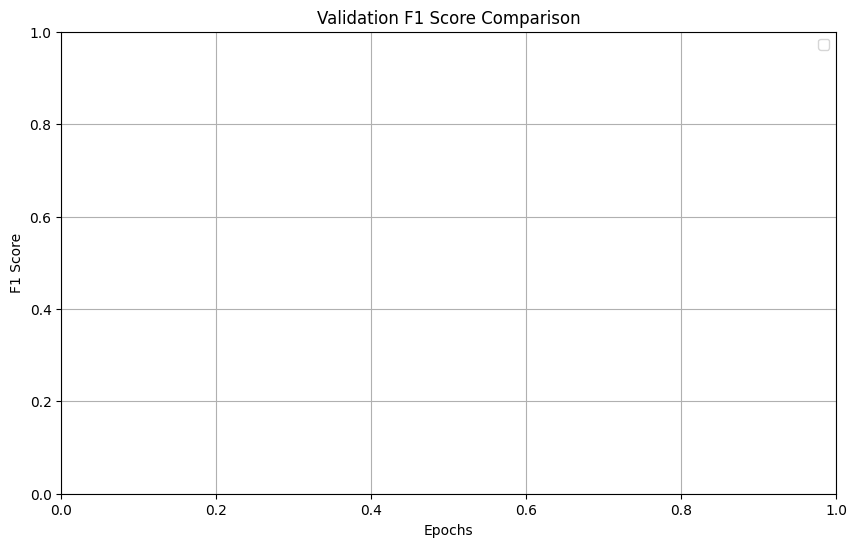

In [34]:
import matplotlib.pyplot as plt
results_dir = os.path.join(Config.PROJECT_ROOT, 'results')

if os.path.exists(results_dir):
    plt.figure(figsize=(10, 6))
    files = [f for f in os.listdir(results_dir) if f.startswith('history_') and f.endswith('.json')]

    for f in files:
        config_name = f.replace('history_', '').replace('.json', '')
        path = os.path.join(results_dir, f)
        with open(path, 'r') as json_file:
            history = json.load(json_file)
        f1_scores = history.get('val_f1', [])
        epochs_range = range(1, len(f1_scores) + 1)
        plt.plot(epochs_range, f1_scores, label=f'Config {config_name}')

    plt.title('Validation F1 Score Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No results to display.")